# 4 site exact solutions

Created 04/05/2025

Objectives:
* Find exact solutions with boundary operators of width 4.

# Package imports

In [1]:
import sys
sys.path.append('../../')

In [2]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os
import pickle

In [86]:
from itertools import chain, combinations
from collections import defaultdict
from functools import reduce
import re

In [4]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.ticker import AutoMinorLocator, MultipleLocator

In [5]:
from tqdm import tqdm

In [6]:
import quimb as qu
import quimb.tensor as qtn

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


In [7]:
#from SPTOptimization.Optimizers.utils import to_npc_array

# Load data

In [7]:
DATA_DIR_1 = r"../../data/finite_cluster_x_transverse_to_product_stacked_cluster_200_site"
DATA_DIR_2 = r"../../data/finite_x_product_stacked_transverse_y_cluster_to_product_200_site"

In [8]:
loaded_data_1 = list()

for local_file_name in os.listdir(DATA_DIR_1):
    if local_file_name[-3:] == '.h5':
        f_name = r"{}/{}".format(DATA_DIR_1, local_file_name, ignore_unknown=False)
        with h5py.File(f_name, 'r') as f:
            data = hdf5_io.load_from_hdf5(f)
            loaded_data_1.append(data)

loaded_data_2 = list()

for local_file_name in os.listdir(DATA_DIR_2):
    if local_file_name[-3:] == '.h5':
        f_name = r"{}/{}".format(DATA_DIR_2, local_file_name, ignore_unknown=False)
        with h5py.File(f_name, 'r') as f:
            data = hdf5_io.load_from_hdf5(f)
            loaded_data_2.append(data)

In [11]:
t_parameters = sorted(list(d['paramters']['interpolation'] for d in loaded_data_1))

In [12]:
psi_dict = dict()

In [14]:
for b in t_parameters:
    mps_psi = next(
        d['wavefunction']
        for d in loaded_data_1
        if d['paramters']['interpolation'] == b
    )

    psi_arrays = list()
    psi_arrays.append(mps_psi.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, mps_psi.L-1):
        psi_arrays.append(mps_psi.get_B(i).to_ndarray())
    psi_arrays.append(mps_psi.get_B(mps_psi.L-1)[..., 0].to_ndarray())

    quimb_psi = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    rounded_b = round(b, 1)
    psi_dict[rounded_b] = quimb_psi

for b in t_parameters:
    mps_psi = next(
        d['wavefunction']
        for d in loaded_data_2
        if d['paramters']['interpolation'] == b
    )

    psi_arrays = list()
    psi_arrays.append(mps_psi.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, mps_psi.L-1):
        psi_arrays.append(mps_psi.get_B(i).to_ndarray())
    psi_arrays.append(mps_psi.get_B(mps_psi.L-1)[..., 0].to_ndarray())

    quimb_psi = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    rounded_b = round(b, 1)
    psi_dict[rounded_b+1] = quimb_psi

# Definitons

In [15]:
MAX_VIRTUAL_BOND_DIM = 8
MAX_INTERMEDIATE_VIRTUAL_BOND_DIM = 2*MAX_VIRTUAL_BOND_DIM
# MPO bond dim?
MAX_MPO_BOND_DIM = 50

SVD_CUTOFF = 1e-3

Define bosonic symmetries. Label by the group element added.

In [16]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Y = np.array([[0,-1j],[1j,0]])
np_Z = np.array([[1,0],[0,-1]])

In [15]:
"""
npc_I = to_npc_array(np_I)
npc_X = to_npc_array(np_X)
npc_Y = to_npc_array(np_Y)
npc_Z = to_npc_array(np_Z)
"""

'\nnpc_I = to_npc_array(np_I)\nnpc_X = to_npc_array(np_X)\nnpc_Y = to_npc_array(np_Y)\nnpc_Z = to_npc_array(np_Z)\n'

In [18]:
def generate_problem_rdm(quimb_psi, symmetry_site_pairs, leftmost_symmetry_site,
                         num_symmetry_sites, num_boundary_sites,
                         antilinear=False, interior=False):
    # Being careful to conjugate the top tensors.
    q_top = quimb_psi.copy(deep=True)

    for i, s in symmetry_site_pairs:
        if antilinear:
            q_top[i].modify(
                data=q_top[i].data.conj()
            )
        q_top.gate(
            s,
            where=i,
            contract=False,
            inplace=True
        )

    shift = num_boundary_sites if interior else False
    left_boundary_sites = list(range(
        leftmost_symmetry_site-num_boundary_sites + shift,
        leftmost_symmetry_site+shift
    ))

    right_boundary_sites = list(range(
        leftmost_symmetry_site+num_symmetry_sites-shift,
        leftmost_symmetry_site+num_symmetry_sites+num_boundary_sites-shift
    ))
    
    indices_to_map = list(chain(left_boundary_sites, right_boundary_sites))

    index_mapping = {f'k{i}': f'b{i}' for i in indices_to_map}

    q_bottom = (
        quimb_psi
        .copy()
        .reindex(index_mapping, inplace=True)
        .conj()
    )

    sites_to_contract = {
        'left': list(range(leftmost_symmetry_site-num_boundary_sites+shift)),
        'middle': list(range(leftmost_symmetry_site+shift, leftmost_symmetry_site+num_symmetry_sites-shift)),
        'right': list(range(leftmost_symmetry_site+num_symmetry_sites+num_boundary_sites-shift, quimb_psi.L))
    }

    tags_to_contract = {
        k: [f'I{i}' for i in v]
        for k, v in sites_to_contract.items()
    }

    tn = (q_top & q_bottom)

    """
    tnc = (
        tn
        .contract(tags_to_contract['left'])
        .contract(tags_to_contract['middle'])
        .contract(tags_to_contract['right'])
    )
    """

    tnc = tn.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_boundary_sites)),
        ('b_left', (f'b{i}' for i in left_boundary_sites)),
        ('k_right', (f'k{i}' for i in right_boundary_sites)),
        ('b_right', (f'b{i}' for i in right_boundary_sites))
    ]

    tnc.fuse(fuse_maps, inplace=True)

    return tnc

## Optimisation functions

In [20]:
def solve_for_boundary_operators(rdm, num_iters=20):
    scores = list()

    # Hard code warning
    u_left = qtn.tensor_builder.rand_tensor(
        (16, 16),
        inds=['k_left', 'b_left'],
        dtype='complex64'
    )

    u_right = qtn.tensor_builder.rand_tensor(
        (16, 16),
        inds=['k_right', 'b_right'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_rdm = (rdm & u_left).contract()
        data = right_rdm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_right = qtn.Tensor(sol, inds = ['b_right', 'k_right'])
        
        left_rdm = (rdm & u_right).contract()
        data = left_rdm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_left = qtn.Tensor(sol, inds = ['b_left', 'k_left'])

    return (u_left, u_right), scores

## SPT functions

In [21]:
def calculate_proj_rep_phase(state_g, left_schmidt_values_g, unitary_h,
                             state_gh,
                             left_environment,
                             max_virtual_bond_dim=MAX_VIRTUAL_BOND_DIM):
    prod_state, _ = multiply_stacked_unitaries_against_mps(
        unitary_h,
        state_g,
        left_schmidt_values_g,
        max_virtual_bond_dim
    )

    exp = inner_product_b_tensors(prod_state, state_gh, left_environment)

    return exp/(np.abs(exp))

In [22]:
def get_proj_rep_phases(mps_tensors, left_schmidt_values, unitaries,
                        left_environment):
    mps_dict = {
        k: v for k, v in zip(symmetry_labels[1:], mps_tensors)
    }

    schmidt_vals_dict = {
        k: v for k, v in zip(symmetry_labels[1:], left_schmidt_values)
    }

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    out_phases = list()

    for a, b, c in group_products:
        phase = calculate_proj_rep_phase(
            mps_dict[a],
            schmidt_vals_dict[a],
            unitaries_dict[b],
            mps_dict[c],
            left_environment,
            max_virtual_bond_dim=MAX_VIRTUAL_BOND_DIM
        )

        out_phases.append(phase)

    return out_phases

In [23]:
def get_right_proj_rep_phases_from_optimizers(optimizers):
    mps_tensors = [
        o.top_right_mps_tensors
        for o in optimizers[1:]
    ]

    left_schmidt_values = [
        o.current_right_side_left_schmidt_values
        for o in optimizers[1:]
    ]

    unitaries = [
        o.right_unitaries for o in optimizers[1:]
    ]

    left_environment = optimizers[0].right_side_left_symmetry_environment

    out = get_proj_rep_phases(
        mps_tensors,
        left_schmidt_values,
        unitaries,
        left_environment
    )

    return out

In [24]:
def get_left_proj_rep_phases_from_optimizers(optimizers):
    mps_tensors = [
        o.top_left_mps_tensors
        for o in optimizers[1:]
    ]

    left_schmidt_values = [
        o.current_left_side_right_schmidt_values
        for o in optimizers[1:]
    ]

    unitaries = [
        o.left_unitaries for o in optimizers[1:]
    ]

    left_environment = optimizers[0].left_side_right_symmetry_environment

    out = get_proj_rep_phases(
        mps_tensors,
        left_schmidt_values,
        unitaries,
        left_environment
    )

    return out

## SPT extraction functions

In [66]:
# Boolean indicates if the symmetry is anti-linear or not.
symmetry_actions = [
    ([np_I, np_I], False),
    ([np_X, np_I], False),
    ([np_I, np_X], True),
    ([np_X, np_X], True)
]

In [67]:
symmetry_labels = [
    'I-I',
    'X-I',
    'I-XK',
    'X-XK'
]

In [68]:
e, a, b, c = symmetry_labels

In [69]:
group_products = [
    (a, a, e),
    (b, b, e),
    (c, c, e),
    (a, b, c),
    (b, a, c),
    (a, c, b),
    (c, a, b),
    (b, c, a),
    (c, b, a),
]

In [88]:
def multi_kron(arrays):
    return reduce(lambda X, Y: np.kron(X, Y), arrays)

In [92]:
symmetry_actions_dict = {
    'I-I': (np.identity(16), False),
    'X-I': (multi_kron([np_X, np_I, np_X, np_I]), False),
    'I-XK': (multi_kron([np_I, np_X, np_I, np_X]), True),
    'X-XK': (multi_kron([np_X, np_X, np_X, np_X]), True)
}

In [93]:
antilinear_dict = {
    e: False,
    a: False,
    b: True,
    c: True
}

In [70]:
def relabel_mpo(mpo, k_label, b_label):
    site_locs = [
        int(k[1:]) for k in mpo.tag_map
        if bool(re.search(regex_p, k))
    ]

    k_in_indices = [f'k{i}' for i in site_locs]
    j_in_indices = [f'b{i}' for i in site_locs]

    k_out_indices = [f'{k_label}{i}' for i in site_locs]
    j_out_indices = [f'{b_label}{i}' for i in site_locs]

    mapping = dict(
        chain(
            zip(k_in_indices, k_out_indices),
            zip(j_in_indices, j_out_indices)
        )
    )

    mpo.reindex(mapping, inplace=True)

In [64]:
def get_proj_rep_phase(rho, u_g, u_h, u_gh):
    m = (u_gh.conj().T) @ u_h @ u_g @ rho
    exp = np.trace(m)

    out = exp/np.abs(exp)

    return out

In [74]:
np_I_4 = np.identity(16)

In [75]:
# Duplicate definition here...!
def get_proj_rep_phases(rho, unitaries):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    unitaries_dict['I-I'] = np_I_4

    out_phases = list()
    for a, b, c in group_products:
        phase = get_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c]
        )

        out_phases.append(phase)

    return out_phases

In [94]:
# Hard code warning!
# This code might be assuming the group is Abelian? Check Kapustin index formula in nonAbelian case.
def get_interior_proj_rep_phase(rho, u_g, u_h, u_gh, g_symmetry_label):
    g_sym, antilinear = symmetry_actions_dict[g_symmetry_label]

    m_h = u_h.conj() if antilinear else u_h

    m = (
        (u_gh.conj().T)
        @ g_sym
        @ m_h
        @ (g_sym.conj().T)
        @ u_g
        @ rho
    )
    exp = np.trace(m)

    out = exp/np.abs(exp)

    return out

In [99]:
# Duplicate definition here...!
def get_interior_proj_rep_phases(rho, unitaries):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    unitaries_dict['I-I'] = np_I_4

    out_phases = list()
    for a, b, c in group_products:
        phase = get_interior_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c],
            a
        )

        out_phases.append(phase)

    return out_phases

# Calculate boundary operators
## Exterior

In [106]:
num_boundary_sites=4
left_most_symmetry_site=60
num_symmetry_sites=80

symmetry_sites = list(range(
    leftmost_symmetry_site,
    leftmost_symmetry_site+num_symmetry_sites
))

In [107]:
num_iterations = 3

In [108]:
results_dict = dict()

for k1, psi in tqdm(psi_dict.items()):
    for k2, (bs, antilinear) in enumerate(symmetry_actions[1:], start=1):
        symmetry_site_pairs = (
            [(i, bs[0]) for i in range(left_most_symmetry_site, left_most_symmetry_site+num_symmetry_sites, 2)]
            + [(i, bs[1]) for i in range(left_most_symmetry_site+1, left_most_symmetry_site+num_symmetry_sites+1, 2)]
        )
    
        rdm = generate_problem_rdm(
            psi,
            symmetry_site_pairs,
            leftmost_symmetry_site,
            num_symmetry_sites,
            num_boundary_sites,
            antilinear=antilinear
        )
    
        (u_left, u_right), scores = solve_for_boundary_operators(
            rdm,
            num_iters=num_iterations
        )
    
        results_dict[(k1, k2)] = (u_left, u_right), scores

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [01:06<00:00,  3.18s/it]


### Check results

In [109]:
t_params = np.round(np.linspace(0, 2, 21), 1)

In [110]:
t_params

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. ])

In [111]:
scores = list()
for t in t_params:

    scores.append([results_dict[(t, i)][1][-1] for i in [1,2,3]])

scores = np.array(scores)

In [112]:
scores.shape

(21, 3)

In [113]:
colors = [
    'tab:blue',
    'tab:orange',
    'tab:green'
]   

Text(0.5, 0.98, 'Final overlap $\\vert c \\vert$ with symmetry $g$ as a function of $B$')

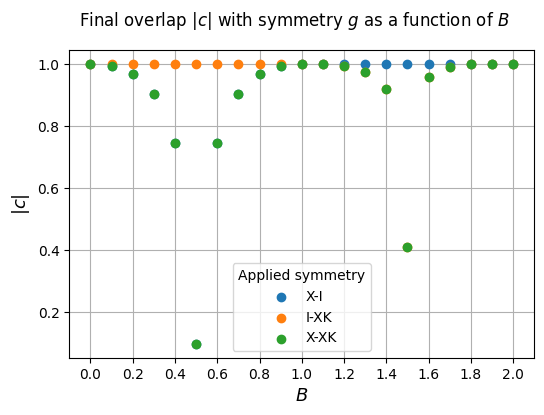

In [114]:
fig, ax = plt.subplots(figsize=(6,4))

for j, (col, label) in enumerate(zip(colors, symmetry_labels[1:])):
    plt.scatter(
        t_params,
        scores[:, j],
        color=col,
        label = label
    )

ax.xaxis.set_major_locator(
    matplotlib.ticker.MultipleLocator(0.2)
)

#ax.set_yscale('log')

ax.grid()
ax.grid(
    which='minor',
    axis='y',
    linestyle='--',
    zorder=-1e10
)
ax.set_axisbelow(True)

ax.set_ylabel(r'$\vert c\vert$', fontsize=13)
ax.set_xlabel('$B$', fontsize=13)

ax.legend(loc='lower center', title='Applied symmetry')

fig.suptitle(r'Final overlap $\vert c \vert$ with symmetry $g$ as a function of $B$')

#fig.savefig(r'plots/ed_cost_function_from_svd_bosonic.png', dpi=200)

In [115]:
np.round(scores, 3)

array([[1.   , 1.   , 1.   ],
       [0.994, 1.   , 0.994],
       [0.968, 1.   , 0.968],
       [0.904, 1.   , 0.904],
       [0.746, 1.   , 0.746],
       [0.098, 1.   , 0.098],
       [0.746, 1.   , 0.746],
       [0.904, 1.   , 0.904],
       [0.968, 1.   , 0.968],
       [0.994, 1.   , 0.994],
       [1.   , 1.   , 1.   ],
       [1.   , 0.999, 0.999],
       [1.   , 0.992, 0.992],
       [1.   , 0.972, 0.972],
       [1.   , 0.918, 0.918],
       [1.   , 0.408, 0.408],
       [1.   , 0.957, 0.957],
       [1.   , 0.989, 0.989],
       [1.   , 0.998, 0.998],
       [1.   , 0.999, 0.999],
       [1.   , 1.   , 1.   ]])

In [116]:
exterior_scores = scores

Why are the boundary operator scores so good...?

In [126]:
np.round(results_dict[(0, 1)][0][1].data, 3)

array([[ 0.   -0.j   ,  0.   +0.j   , -0.   -0.j   ,  0.   +0.j   ,
        -0.   -0.j   ,  0.   -0.j   ,  0.   +0.j   ,  0.   +0.j   ,
         0.845+0.534j, -0.   -0.j   , -0.   -0.j   , -0.   -0.j   ,
        -0.   -0.j   , -0.   -0.j   , -0.   -0.j   ,  0.   +0.j   ],
       [-0.   +0.j   ,  0.   +0.j   , -0.   -0.j   , -0.   -0.j   ,
        -0.   -0.j   ,  0.   +0.j   ,  0.   +0.j   , -0.   -0.j   ,
         0.   +0.j   ,  0.845+0.534j,  0.   +0.j   , -0.   -0.j   ,
         0.   +0.j   , -0.   -0.j   , -0.   -0.j   , -0.   -0.j   ],
       [-0.   -0.j   ,  0.   -0.j   , -0.   -0.j   , -0.   -0.j   ,
        -0.   -0.j   , -0.   -0.j   , -0.   -0.j   , -0.   +0.j   ,
        -0.   -0.j   ,  0.   -0.j   , -0.845-0.534j,  0.   +0.j   ,
        -0.   -0.j   , -0.   -0.j   , -0.   -0.j   , -0.   -0.j   ],
       [-0.   -0.j   ,  0.   +0.j   , -0.   -0.j   , -0.   +0.j   ,
        -0.   -0.j   ,  0.   -0.j   ,  0.   -0.j   ,  0.   +0.j   ,
        -0.   -0.j   , -0.   -0.j   ,  0.   +

In [117]:
proj_rep_phases = list()

for t in tqdm(t_params):
    psi = psi_dict[t]

    rdm = generate_problem_rdm(
        psi,
        [],
        leftmost_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites
    )

    left_rdm = (
        rdm
        .trace('b_right', 'k_right')
        .transpose('k_left', 'b_left')
        .data
    )
    right_rdm = (
        rdm
        .trace('b_left', 'k_left')
        .transpose('k_right', 'b_right')
        .data
    )

    unitary_pairs = [results_dict[(t, i)][0] for i in [1,2,3]]
    left_unitaries, right_unitaries = zip(*unitary_pairs)

    left_unitaries = [
        lu.transpose('b_left', 'k_left').data
        for lu in left_unitaries
    ]

    right_unitaries = [
        ru.transpose('b_right', 'k_right').data
        for ru in right_unitaries
    ]
    left_phases = get_proj_rep_phases(left_rdm, left_unitaries)
    right_phases = get_proj_rep_phases(right_rdm, right_unitaries)

    proj_rep_phases.append([left_phases, right_phases])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:22<00:00,  1.09s/it]


In [118]:
proj_rep_phases = np.array(proj_rep_phases)

In [119]:
proj_rep_phases.shape

(21, 2, 9)

In [120]:
np.round(proj_rep_phases, 3)

array([[[-0.429+0.903j,  0.98 -0.199j, -0.942+0.336j,  0.881-0.473j,
          0.881-0.473j, -0.805+0.593j, -0.805+0.593j,  0.958+0.288j,
          0.958+0.288j],
        [-0.429-0.903j,  0.98 +0.199j, -0.942-0.336j,  0.881+0.473j,
          0.881+0.473j, -0.805-0.593j, -0.805-0.593j,  0.958-0.288j,
          0.958-0.288j]],

       [[-0.413+0.911j, -0.437+0.899j,  0.942+0.335j, -0.265+0.964j,
         -0.265+0.964j,  0.988+0.157j,  0.988+0.157j,  0.983+0.183j,
          0.983+0.183j],
        [-0.413-0.911j, -0.437-0.899j,  0.942-0.335j, -0.265-0.964j,
         -0.265-0.964j,  0.988-0.157j,  0.988-0.157j,  0.983-0.183j,
          0.983-0.183j]],

       [[-0.385+0.923j,  0.654-0.757j, -0.026-1.j   , -0.217-0.976j,
         -0.217-0.976j, -0.817-0.576j, -0.817-0.576j,  0.597+0.802j,
          0.597+0.802j],
        [-0.385-0.923j,  0.654+0.757j, -0.026+1.j   , -0.217+0.976j,
         -0.217+0.976j, -0.817+0.576j, -0.817+0.576j,  0.597-0.802j,
          0.597-0.802j]],

       [[ 0.804+

## Interior

In [81]:
results_dict = dict()

for k1, psi in tqdm(psi_dict.items()):
    for k2, (bs, antilinear) in enumerate(symmetry_actions[1:], start=1):
        symmetry_site_pairs = (
            [(i, bs[0]) for i in range(left_most_symmetry_site, left_most_symmetry_site+num_symmetry_sites, 2)]
            + [(i, bs[1]) for i in range(left_most_symmetry_site+1, left_most_symmetry_site+num_symmetry_sites+1, 2)]
        )
    
        rdm = generate_problem_rdm(
            psi,
            symmetry_site_pairs,
            leftmost_symmetry_site,
            num_symmetry_sites,
            num_boundary_sites,
            antilinear=antilinear,
            interior=True
            
        )
    
        (u_left, u_right), scores = solve_for_boundary_operators(
            rdm,
            num_iters=num_iterations
        )
    
        results_dict[(k1, k2)] = (u_left, u_right), scores

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [01:08<00:00,  3.24s/it]


In [82]:
scores = list()
for t in t_params:

    scores.append([results_dict[(t, i)][1][-1] for i in [1,2,3]])

scores = np.array(scores)

In [83]:
scores - exterior_scores

array([[ 2.22044605e-16,  2.22044605e-16, -4.44089210e-16],
       [ 1.58761893e-14,  1.55431223e-15,  1.56541446e-14],
       [-1.84019466e-12,  3.33066907e-16, -1.84019466e-12],
       [ 5.81312776e-13, -1.33226763e-15,  5.82311976e-13],
       [-2.19280618e-06, -1.77635684e-15, -2.19280618e-06],
       [ 1.12477800e-02,  1.33226763e-15,  1.12365284e-02],
       [-7.47302631e-06,  3.66373598e-15, -7.67242035e-06],
       [ 3.81960560e-07,  7.98973132e-09,  3.88039153e-07],
       [ 2.40089948e-09,  1.44328993e-15,  2.40090581e-09],
       [ 1.95277128e-12, -6.66133815e-16,  1.95232719e-12],
       [-6.66133815e-16,  0.00000000e+00, -4.44089210e-16],
       [ 1.33226763e-15,  1.00519988e-06,  1.00519988e-06],
       [-4.44089210e-16,  5.53299993e-04,  5.53299993e-04],
       [ 1.77635684e-15, -4.84358027e-03, -4.84358027e-03],
       [-4.44089210e-16, -6.47037180e-03, -6.47037180e-03],
       [ 1.00475184e-13, -3.81848874e-03, -3.81842295e-03],
       [-8.88178420e-16, -1.01086385e-02

Very small difference...

Text(0.5, 0.98, 'Final overlap $\\vert c \\vert$ with symmetry $g$ as a function of $B$')

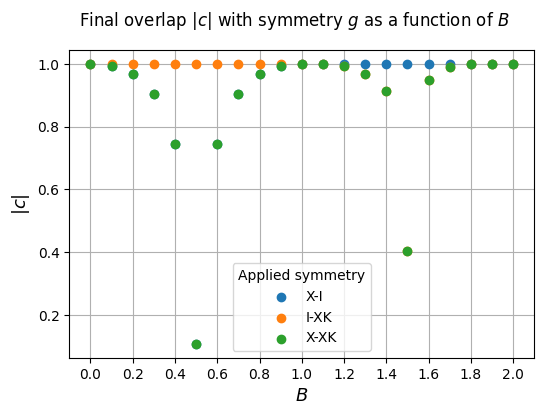

In [84]:
fig, ax = plt.subplots(figsize=(6,4))

for j, (col, label) in enumerate(zip(colors, symmetry_labels[1:])):
    plt.scatter(
        t_params,
        scores[:, j],
        color=col,
        label = label
    )

ax.xaxis.set_major_locator(
    matplotlib.ticker.MultipleLocator(0.2)
)

#ax.set_yscale('log')

ax.grid()
ax.grid(
    which='minor',
    axis='y',
    linestyle='--',
    zorder=-1e10
)
ax.set_axisbelow(True)

ax.set_ylabel(r'$\vert c\vert$', fontsize=13)
ax.set_xlabel('$B$', fontsize=13)

ax.legend(loc='lower center', title='Applied symmetry')

fig.suptitle(r'Final overlap $\vert c \vert$ with symmetry $g$ as a function of $B$')

#fig.savefig(r'plots/ed_cost_function_from_svd_bosonic.png', dpi=200)

In [100]:
proj_rep_phases = list()

for t in tqdm(t_params):
    psi = psi_dict[t]

    rdm = generate_problem_rdm(
        psi,
        [],
        leftmost_symmetry_site,
        num_symmetry_sites,
        num_boundary_sites
    )

    left_rdm = (
        rdm
        .trace('b_right', 'k_right')
        .transpose('k_left', 'b_left')
        .data
    )
    right_rdm = (
        rdm
        .trace('b_left', 'k_left')
        .transpose('k_right', 'b_right')
        .data
    )

    unitary_pairs = [results_dict[(t, i)][0] for i in [1,2,3]]
    left_unitaries, right_unitaries = zip(*unitary_pairs)

    left_unitaries = [
        lu.transpose('b_left', 'k_left').data
        for lu in left_unitaries
    ]
    right_unitaries = [
        ru.transpose('b_right', 'k_right').data
        for ru in right_unitaries
    ]

    left_phases = get_interior_proj_rep_phases(
        left_rdm,
        left_unitaries
    )
    right_phases = get_interior_proj_rep_phases(
        right_rdm,
        right_unitaries
    )

    proj_rep_phases.append([left_phases, right_phases])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:22<00:00,  1.07s/it]


In [101]:
proj_rep_phases = np.array(proj_rep_phases)

In [104]:
proj_rep_phases.shape

(21, 2, 9)

In [103]:
np.round(proj_rep_phases, 3)

array([[[ 0.453+0.892j, -1.   +0.j   ,  1.   +0.j   , -0.325-0.946j,
          0.99 +0.138j, -0.99 +0.138j,  0.325-0.946j, -0.99 -0.138j,
          0.325-0.946j],
        [ 0.453-0.892j, -1.   -0.j   ,  1.   -0.j   , -0.325+0.946j,
          0.99 -0.138j, -0.99 -0.138j,  0.325+0.946j, -0.99 +0.138j,
          0.325+0.946j]],

       [[ 0.992+0.123j, -1.   +0.j   ,  1.   -0.j   , -0.939+0.344j,
          0.89 -0.457j, -0.89 -0.457j,  0.939+0.344j, -0.89 +0.457j,
          0.939+0.344j],
        [ 0.992-0.123j, -1.   -0.j   ,  1.   +0.j   , -0.939-0.344j,
          0.89 +0.457j, -0.89 +0.457j,  0.939-0.344j, -0.89 -0.457j,
          0.939-0.344j]],

       [[ 0.252+0.968j, -1.   +0.j   ,  1.   -0.j   , -0.64 -0.768j,
          0.905-0.426j, -0.905-0.426j,  0.64 -0.768j, -0.905+0.426j,
          0.64 -0.768j],
        [ 0.252-0.968j, -1.   -0.j   ,  1.   +0.j   , -0.64 +0.768j,
          0.905+0.426j, -0.905+0.426j,  0.64 +0.768j, -0.905-0.426j,
          0.64 +0.768j]],

       [[-0.938-

In [105]:
np.round(proj_rep_phases[...,1:3], 3)

array([[[-1.+0.j,  1.+0.j],
        [-1.-0.j,  1.-0.j]],

       [[-1.+0.j,  1.-0.j],
        [-1.-0.j,  1.+0.j]],

       [[-1.+0.j,  1.-0.j],
        [-1.-0.j,  1.+0.j]],

       [[-1.-0.j,  1.+0.j],
        [-1.-0.j,  1.+0.j]],

       [[-1.+0.j,  1.+0.j],
        [-1.-0.j,  1.-0.j]],

       [[-1.-0.j, -1.-0.j],
        [-1.+0.j, -1.-0.j]],

       [[-1.-0.j, -1.-0.j],
        [-1.+0.j, -1.+0.j]],

       [[-1.+0.j, -1.+0.j],
        [-1.+0.j, -1.+0.j]],

       [[-1.-0.j, -1.-0.j],
        [-1.+0.j, -1.+0.j]],

       [[-1.-0.j, -1.+0.j],
        [-1.-0.j, -1.-0.j]],

       [[-1.-0.j, -1.+0.j],
        [-1.-0.j, -1.-0.j]],

       [[-1.+0.j, -1.-0.j],
        [-1.-0.j, -1.-0.j]],

       [[-1.+0.j, -1.+0.j],
        [-1.+0.j, -1.+0.j]],

       [[-1.+0.j, -1.+0.j],
        [-1.-0.j, -1.-0.j]],

       [[-1.-0.j, -1.-0.j],
        [-1.+0.j, -1.+0.j]],

       [[ 1.+0.j,  1.+0.j],
        [ 1.+0.j,  1.+0.j]],

       [[ 1.-0.j,  1.-0.j],
        [ 1.-0.j,  1.+0.j]],

       [[ 1.+0